### UK-based Online Retail Transaction Data (Online Retail II UCI - Kaggle) - ETL Project
https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

### Attribute Information:

1. Invoice: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
2. StockCode: Product code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
3. Description: Product (item) name. Nominal.
4. Quantity: The quantities of each product (item) per transaction. Numeric.
5. InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
6. Price: Unit price. Numeric. Product price per unit in sterling (Â£).
7. Customer ID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
8. Country: Country name. Nominal. The name of the country where a customer resides.

## Import Libraries and Upload Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Extract Data 

In [2]:
# Upload dataset
df = pd.read_csv('online_retail_II.csv')

In [3]:
# Explore data by displaying first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# Display the shape of data (rows first, then columns)
print(df.shape)

(1067371, 8)


In [5]:
# Display column data types (Insight: InvoiceDate should be datetime not object (string)) 
df.dtypes 

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

## 2. Transform - Data Cleaning

### 2.1. Datatype Errors Fix

In [6]:
# Fix data type for InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

### 2.2. Duplicates Confirm and Drop

In [7]:
# Check for duplicate rows (it only dispalys 
df.duplicated().sum()

np.int64(34335)

In [8]:
df[df.duplicated(keep=False)].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [9]:
# Display the duplicate rows to confirm if duplicates are real, and just scattered by row position, by sorting them into view.
df[df['Invoice'] == '489517'].sort_values(['StockCode', 'Description', 'Quantity', 'Price'])

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
364,489517,16207A,PINK STRAWBERRY HANDBAG,2,2009-12-01 11:34:00,2.95,16329.0,United Kingdom
398,489517,20675,BLUE SPOTTY BOWL,4,2009-12-01 11:34:00,1.25,16329.0,United Kingdom
375,489517,20711,JUMBO BAG TOYS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
381,489517,20971,PINK BLUE FELT CRAFT TRINKET BOX,1,2009-12-01 11:34:00,1.25,16329.0,United Kingdom
370,489517,20972,PINK CREAM FELT CRAFT TRINKET BOX,1,2009-12-01 11:34:00,1.25,16329.0,United Kingdom
397,489517,21244,BLUE SPOTTY PLATE,4,2009-12-01 11:34:00,1.69,16329.0,United Kingdom
382,489517,21252,SET OF MEADOW FLOWER STICKERS,1,2009-12-01 11:34:00,2.95,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
369,489517,21584,RETRO SPOT SMALL TUBE MATCHES,20,2009-12-01 11:34:00,1.65,16329.0,United Kingdom


In [10]:
# We can drop duplicate rows
df = df.drop_duplicates()

In [11]:
print(df.shape)

(1033036, 8)


### 2.3. Handle Missing Values

In [12]:
# Count null values         --looks like 25% of Customer ID are missing, and small percentage of 4382 Desc
df.isna().sum()

Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

**Insights**
25% of transactions lack a CustomerID. I kept and labeled 'Unknown' rather than dropped, to avoid losing real revenue data. 

In [13]:
# Fill missing values in Customer ID and Description with 'unknown' (for customer level analysis later)
df = df.fillna({'Customer ID': 'Unknown', 'Description': 'Unknown item'})

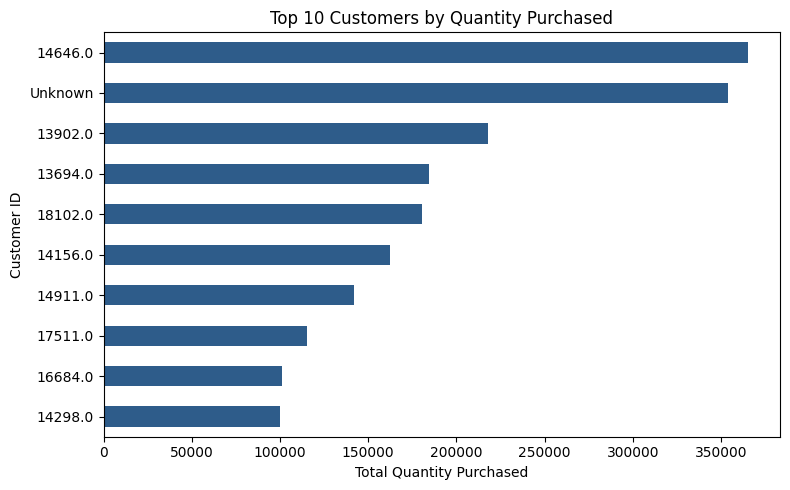

In [14]:
# Visualize the Unkown values in Customer ID
top_customers = df.groupby('Customer ID')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_customers.plot(kind='barh', color='#2E5C8A')
plt.xlabel('Total Quantity Purchased')
plt.ylabel('Customer ID')
plt.title('Top 10 Customers by Quantity Purchased')
plt.gca().invert_yaxis()  # highest value at the top
plt.tight_layout()
plt.show()

### 2.4. Handle Cancellations (Invoices Column)

In [15]:
# Create column of cancelled / returned transactions
df_cancelled = df[df['Invoice'].astype(str).str.startswith('C')] 

In [16]:
df_cancelled.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [27]:
# ~ means "NOT" 
# We can use df_sales in RFM analysis 
df_sales = df[~df['Invoice'].astype(str).str.startswith('C')]

## 3. Transform - Feature Engineering

### 3.1. TotalPrice = Quantity * Price

In [18]:
# Creat a new column for total price 
df['TotalPrice'] = df['Quantity'] * df['Price']

In [19]:
df[['Quantity', 'Price', 'TotalPrice']].head(5)

,Quantity,Price,TotalPrice
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


### 3.2. Extract Year/Month out of InvoiceDate

In [20]:
# Pull out Year
df['Year'] = df['InvoiceDate'].dt.year

In [21]:
# Pull out Month
df['Month'] = df['InvoiceDate'].dt.month

## 4. Exploratory Data Analysis

### 4.1. Top 10 customer chart

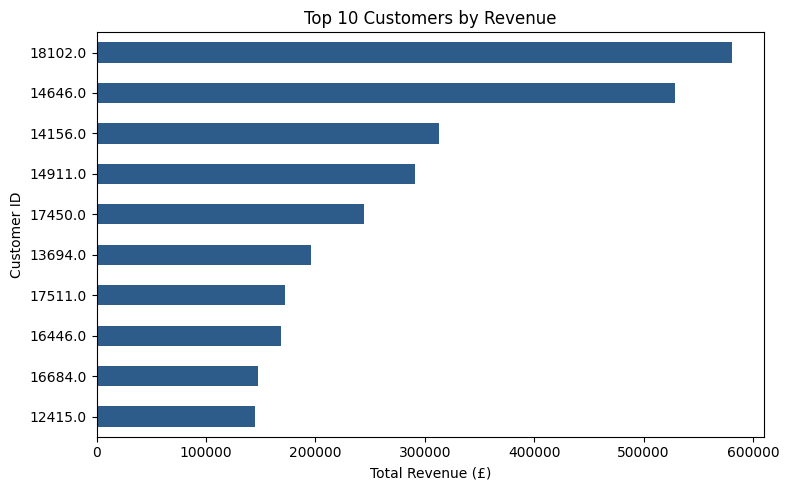

In [59]:
# Top 10 Customer Revenue
top_customers_revenue = (
    df_sales[df_sales['Customer ID'] != 'Unknown'] 
    .groupby('Customer ID')['TotalPrice']                       # () calls a function or an instruction, [] is selecting/indexing TotalPrice from CustomerID = Known grouped object to apply .sum() to 
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
top_customers_revenue.plot(kind='barh', color='#2E5C8A')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Customer ID')
plt.title('Top 10 Customers by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.2. Revenue by Country

Country
United Kingdom    1.725152e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: TotalPrice, dtype: float64


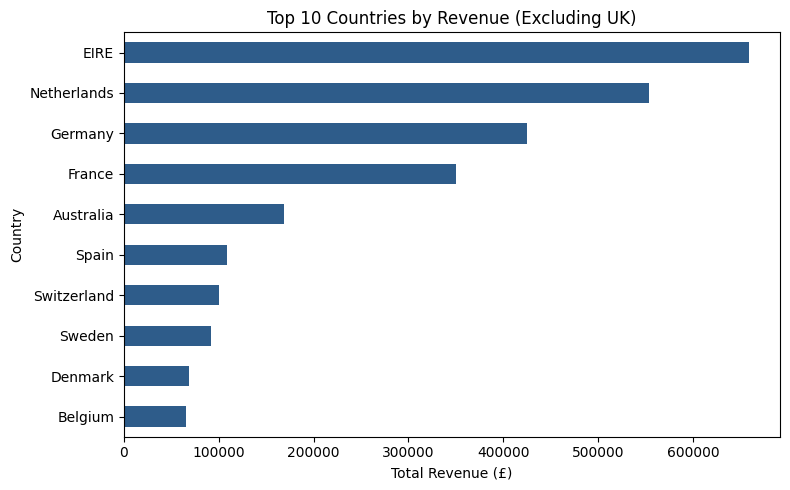

In [57]:
revenue_by_country = df_sales.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
print(revenue_by_country.head(10))

# Visualize everything EXCEPT UK, since UK will dwarf all other bars
top_non_uk = revenue_by_country.drop('United Kingdom').head(10)

plt.figure(figsize=(8, 5))
top_non_uk.plot(kind='barh', color='#2E5C8A')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3. Monthly Trends

In [60]:
# Create a copy of the of the Cancelled Invoices
df_sales = df[~df['Invoice'].astype(str).str.startswith('C')].copy()

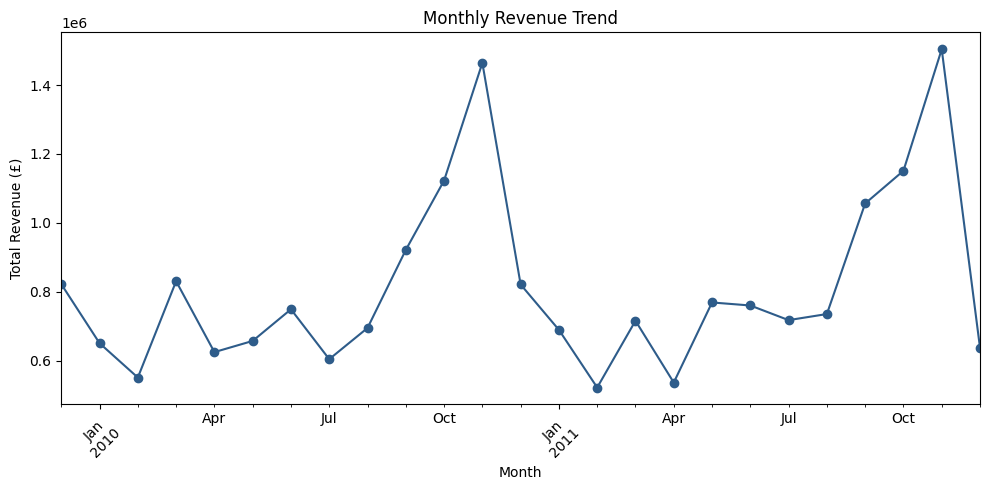

In [61]:
df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M')

monthly_revenue = df_sales.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize=(10, 5))
monthly_revenue.plot(kind='line', marker='o', color='#2E5C8A')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Advanced Analysis

### 5.1. Customer Segmentation (Missing Customer_ID vs. Available)

In [23]:
# Group the column Customer_ID
df['CustomerType'] = df['Customer ID'].apply(lambda x: 'Unknown' if x == 'Unknown' else 'Known')

In [24]:
# Compare the CustomerType Segment
df.groupby('CustomerType').agg({
    'Quantity': 'sum', 
    'Price': 'mean', 
    'TotalPrice': ['sum', 'mean'], 
    'Invoice': 'nunique'
})

Quantity     Price    TotalPrice            Invoice
                   sum      mean           sum       mean nunique
CustomerType                                                     
Known         10055729  3.702732  1.628999e+07  20.416465   44876
Unknown         354050  7.705913  2.565542e+06  10.910191    8752

In [26]:
# Known customers vs Unkown customers' purchase quantity
df.groupby('CustomerType')['Quantity'].mean()

CustomerType
Known      12.602980
Unknown     1.505628
Name: Quantity, dtype: float64

**Key Insight**
- Known customers buy in bulk (~12.6 units/order).
- Unknown customers buy single items at a higher price point
- Suggesting Known = wholesale accounts, Unknown = individual consumers.

### 5.2. RFM Segmentation (Recency, Frequency, and Monetary value)

In [34]:
# RFM analysis cannot include cancelled orders - so we will use df_sales (removing df_cancelled)
# RFM analys can also not include missing CustomerID since we can't measure Frequency for someone we can't identify - so we'll use CustomerID = 'Known' 
df_rfm = df_sales[df_sales['Customer ID'] != 'Unknown']

In [37]:
# Reference date to measure Recency from
recency_date = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

In [40]:
# Build RFM table 
rfm = df_rfm.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (recency_date - x.max()).days,      # Recency (for each customer, most recent purchase date. How many days ago that was from recency date. Smaller = they bought more recently = better)
    'Invoice': 'nunique',                                        # Frequency (count how many distinct invoices each customer has. More = more loyal) 
    'TotalPrice': 'sum'                                          # Monetary (total money spent, using TotalPrice column built earlier)
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [44]:
# Turning each metric into a 1-5 score (as is standard practice in RFM)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])                              # lower recency = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [52]:
# Combine into a segment label
rfm['rfm_score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)        # These are string, so addition will be text concatenation (2,5,5 = 255)! 

def segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'At Risk'
    else:
        return 'Lost!'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [51]:
rfm.head(5)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,rfm_score,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,255,Lost!
12347.0,2,8,4921.53,5,4,5,545,Champions
12348.0,75,5,2019.40,3,4,4,344,Loyal Customers
12349.0,19,4,4428.69,5,3,5,535,Loyal Customers
12350.0,310,1,334.40,2,1,2,212,At Risk


In [63]:
# RFM Segmentation Percentages

# 1. Normalize values
rfm_segment_per = rfm['Segment'].value_counts(normalize=True)*100
print(rfm_segment_per)

Segment
At Risk                25.930964
Loyal Customers        23.924503
Champions              22.054072
Potential Loyalists    14.079238
Lost!                  14.011223
Name: proportion, dtype: float64


In [65]:
# 2. Ger specific numbers
champions_prc = rfm_segment_per.get('Champions', 0)
loyal_customers_prc = rfm_segment_per.get('Loyal Customers', 0)
potential_loyalists_prc = rfm_segment_per.get('Potential Loyalists', 0)
at_risk_prc = rfm_segment_per.get('At Risk', 0) + rfm_segment_per.get('Lost', 0)

In [68]:
# 2. Ger specific numbers
print(f'{champions_prc:.0f}% of customers are "Champions", while {loyal_customers_prc:.0f}% are "Loyal Customers", {potential_loyalists_prc:.0f}% are "Potential Loyalists", and {at_risk_prc:.0f}% fall into "At Risk" or "Lost"')

22% of customers are "Champions", while 24% are "Loyal Customers", 14% are "Potential Loyalists", and 26% fall into "At Risk" or "Lost"


**Insight**
- If we added numbers, a customer with R=5, F=1, M=1 (sum=7),another customer with R=1, F=5, M=1 (sum=7) would get same total score, even if their behavior is different.
- Also, RFM string is used for labeling/filtering ("show me everyone whose code starts with 5"), never for numeric sorting or ranking. 

## 6. Key Insights

- This project started as basic data cleaning practice and became a genuine exercise in slowing down and questioning every assumption. 
- Whether a "duplicate" row was really a duplicate, to what gets lost when you drop missing values without thinking it through.
- The biggest lesson wasn't a pandas function; it was learning to treat every cleaning decision as something I need to be able to explain and defend, not just execute.